In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [5]:
# 1. Load and prepare data
df = pd.read_csv('../Data_Analytics/rte_historical_energy.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [6]:
# Add time-based features
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['month'] = df['Timestamp'].dt.month
df['day'] = df['Timestamp'].dt.day

In [7]:

# Calculate total production
df['Total_Production'] = df['Solaire (MW)'] + df['Éolien (MW)'] + \
                        df['Hydroélectrique (MW)'] + df['Gaz (MW)'] + \
                        df['Cycle à Vapeur (MW)']

In [8]:
# 2. Create features and targets
energy_sources = ['Solaire (MW)', 'Éolien (MW)', 'Hydroélectrique (MW)', 
                    'Gaz (MW)', 'Cycle à Vapeur (MW)', 'Total_Production']

def create_features(df, target_col, lookback=24):
    """Create features using historical data"""
    features = []
    targets = []
    
    for i in range(len(df) - lookback):
        features.append(df[['hour', 'day_of_week', 'month', 'day', target_col]].iloc[i:i+lookback].values)
        targets.append(df[target_col].iloc[i+lookback])
    
    return np.array(features), np.array(targets)

In [9]:
# 3. Train models for each energy source
predictions = {}
models = {}

for source in energy_sources:
    print(f"\nTraining models for {source}")
    
    # Prepare data
    X, y = create_features(df, source)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Reshape for model input
    X_train_2d = X_train.reshape(X_train.shape[0], -1)
    X_test_2d = X_test.reshape(X_test.shape[0], -1)
    
    # Train Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_2d, y_train)
    rf_pred = rf_model.predict(X_test_2d)
    
    # Train XGBoost
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    xgb_model.fit(X_train_2d, y_train)
    xgb_pred = xgb_model.predict(X_test_2d)
    
    # Store predictions and models
    predictions[source] = {
        'rf': rf_pred,
        'xgb': xgb_pred,
        'actual': y_test
    }
    models[source] = {
        'rf': rf_model,
        'xgb': xgb_model
    }
    
    # Print metrics
    print(f"\nRandom Forest Metrics:")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")
    print(f"R2 Score: {r2_score(y_test, rf_pred):.2f}")
    
    print(f"\nXGBoost Metrics:")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f}")
    print(f"R2 Score: {r2_score(y_test, xgb_pred):.2f}")


Training models for Solaire (MW)

Random Forest Metrics:
RMSE: 122.80
R2 Score: -0.02

XGBoost Metrics:
RMSE: 130.02
R2 Score: -0.14

Training models for Éolien (MW)

Random Forest Metrics:
RMSE: 108.85
R2 Score: -0.02

XGBoost Metrics:
RMSE: 122.45
R2 Score: -0.29

Training models for Hydroélectrique (MW)

Random Forest Metrics:
RMSE: 153.88
R2 Score: -0.03

XGBoost Metrics:
RMSE: 171.80
R2 Score: -0.29

Training models for Gaz (MW)

Random Forest Metrics:
RMSE: 225.45
R2 Score: -0.04

XGBoost Metrics:
RMSE: 234.09
R2 Score: -0.12

Training models for Cycle à Vapeur (MW)

Random Forest Metrics:
RMSE: 160.11
R2 Score: -0.05

XGBoost Metrics:
RMSE: 174.91
R2 Score: -0.25

Training models for Total_Production

Random Forest Metrics:
RMSE: 361.46
R2 Score: -0.11

XGBoost Metrics:
RMSE: 379.35
R2 Score: -0.23


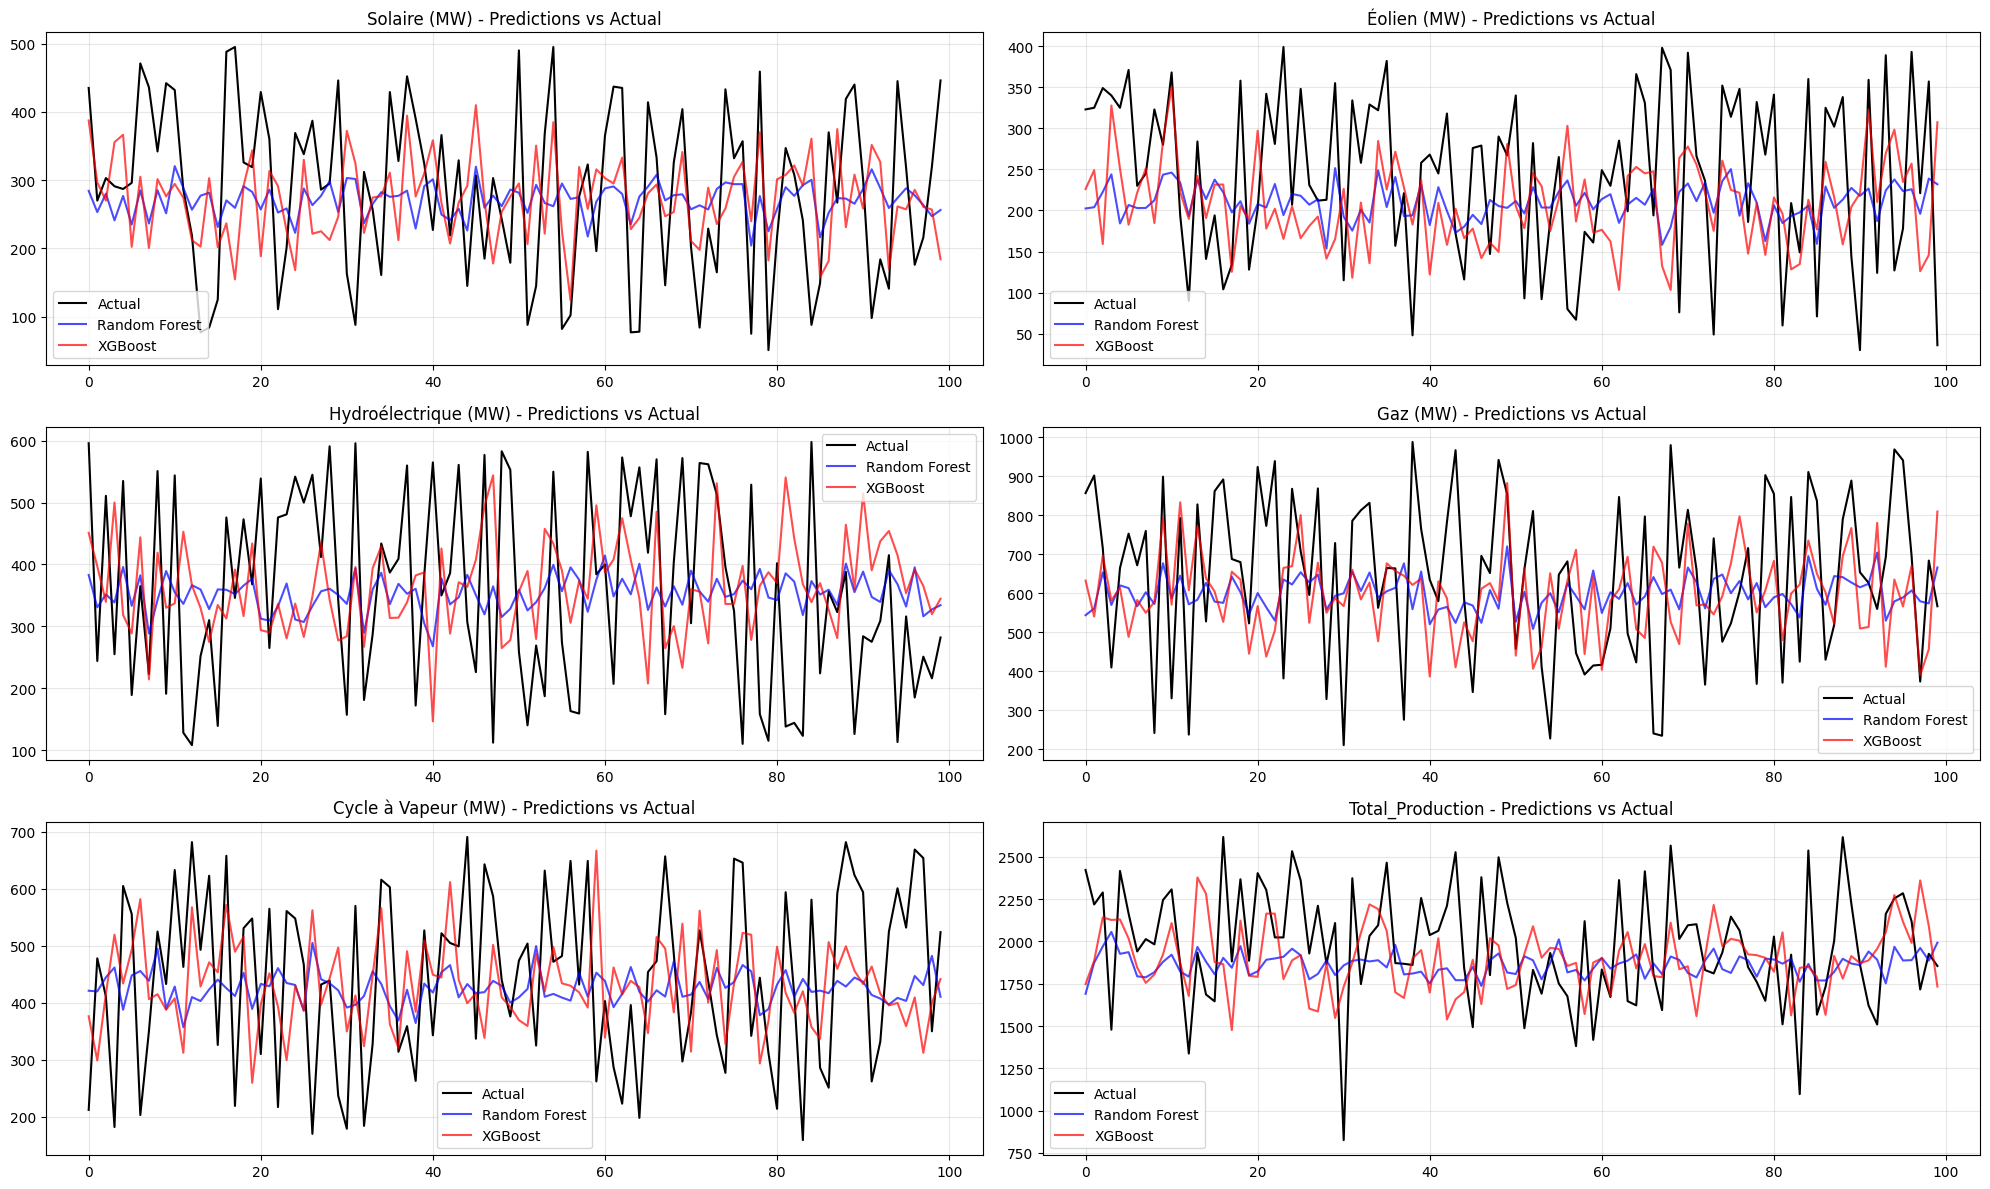

In [10]:
# 4. Visualize predictions vs actual values
plt.figure(figsize=(20, 12))

for idx, source in enumerate(energy_sources, 1):
    plt.subplot(3, 2, idx)
    plt.plot(predictions[source]['actual'][:100], label='Actual', color='black')
    plt.plot(predictions[source]['rf'][:100], label='Random Forest', color='blue', alpha=0.7)
    plt.plot(predictions[source]['xgb'][:100], label='XGBoost', color='red', alpha=0.7)
    plt.title(f'{source} - Predictions vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

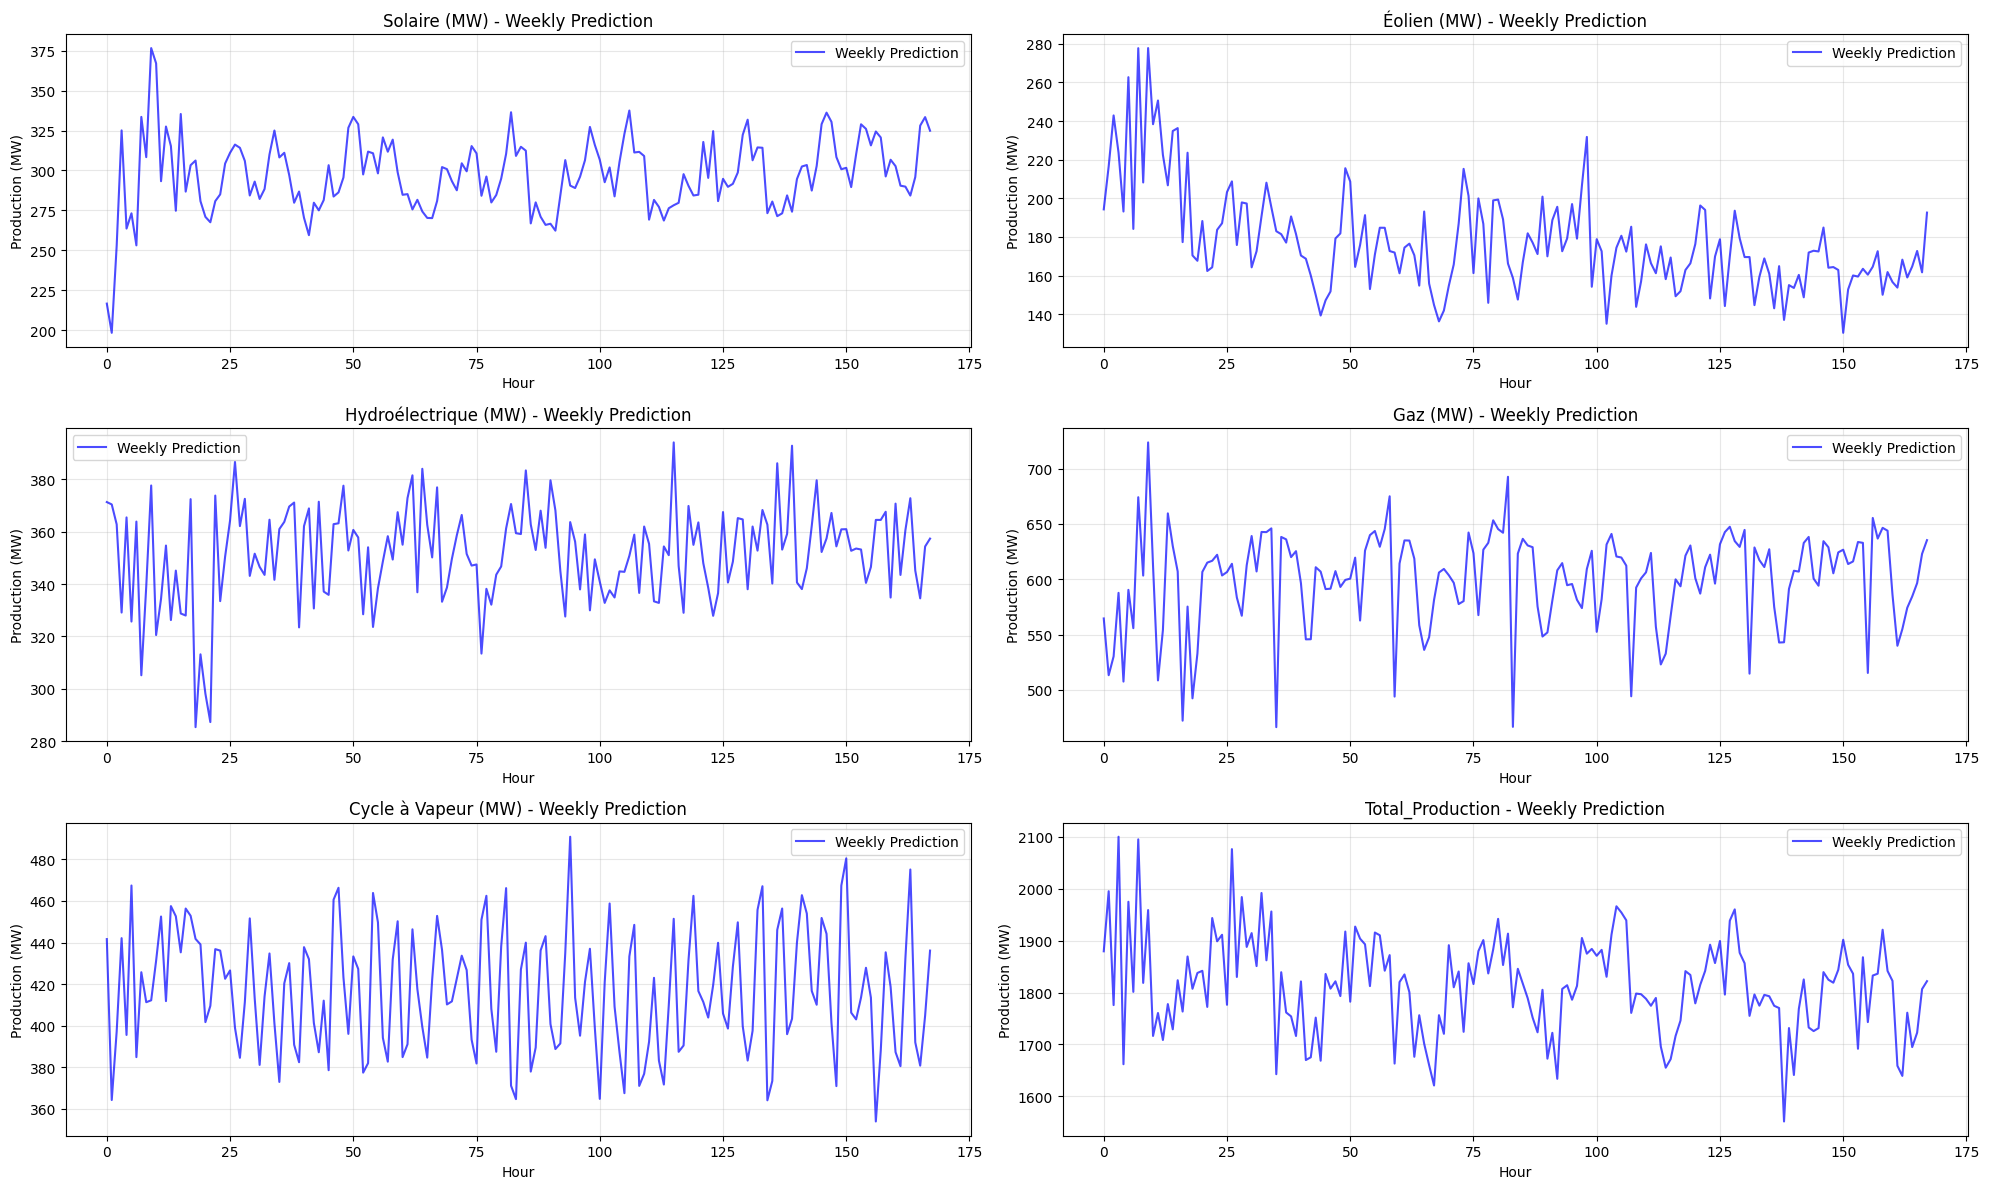


Weekly Average Predictions (MW):
--------------------------------------------------
Solaire (MW): 297.41
Éolien (MW): 177.43
Hydroélectrique (MW): 351.61
Gaz (MW): 599.89
Cycle à Vapeur (MW): 416.88
Total_Production: 1813.88


In [14]:
def make_weekly_predictions(models, last_data):
    predictions_by_hour = {}
    
    # Generate future dates for a week (168 hours)
    future_dates = pd.date_range(start=last_data['Timestamp'].iloc[-1], 
                                periods=169, freq='H')[1:]  # 168 hours + 1 for indexing
    
    for source in energy_sources:
        rf_predictions = []
        xgb_predictions = []
        
        # Get initial last 24 hours of data
        last_values = last_data[source].iloc[-24:].values
        
        # Make predictions for each hour of the week
        for i in range(168):  # 168 hours in a week
            if i == 0:
                historical_data = last_data.iloc[-24:]
            else:
                if i < 24:
                    historical_data = pd.concat([
                        last_data.iloc[-(24-i):],
                        pd.DataFrame({
                            'hour': future_dates[:i].hour,
                            'day_of_week': future_dates[:i].dayofweek,
                            'month': future_dates[:i].month,
                            'day': future_dates[:i].day,
                            source: rf_predictions[:i]
                        })
                    ])
                else:
                    historical_data = pd.DataFrame({
                        'hour': future_dates[i-24:i].hour,
                        'day_of_week': future_dates[i-24:i].dayofweek,
                        'month': future_dates[i-24:i].month,
                        'day': future_dates[i-24:i].day,
                        source: rf_predictions[i-24:i]
                    })

            # Create feature array
            features = np.column_stack([
                historical_data['hour'].values,
                historical_data['day_of_week'].values,
                historical_data['month'].values,
                historical_data['day'].values,
                historical_data[source].values
            ])
            
            X_future = features.reshape(1, -1)
            
            # Make predictions
            rf_pred = models[source]['rf'].predict(X_future)[0]
            xgb_pred = models[source]['xgb'].predict(X_future)[0]
            
            rf_predictions.append(rf_pred)
            xgb_predictions.append(xgb_pred)
        
        # Average predictions from both models
        predictions_by_hour[source] = [(rf + xgb) / 2 for rf, xgb in zip(rf_predictions, xgb_predictions)]
    
    # Plot weekly predictions
    plt.figure(figsize=(20, 12))
    for idx, source in enumerate(energy_sources, 1):
        plt.subplot(3, 2, idx)
        
        plt.plot(range(168), predictions_by_hour[source], 
                 label='Weekly Prediction', color='blue', alpha=0.7)
        
        plt.title(f'{source} - Weekly Prediction')
        plt.xlabel('Hour')
        plt.ylabel('Production (MW)')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print weekly averages
    print("\nWeekly Average Predictions (MW):")
    print("-" * 50)
    for source in energy_sources:
        weekly_avg = np.mean(predictions_by_hour[source])
        print(f"{source}: {weekly_avg:.2f}")
    
    return predictions_by_hour

# Make predictions for next week
weekly_predictions = make_weekly_predictions(models, df)